# 03 — ML training and reconstruction dashboard

This notebook is the heart of CALOMAPS:

1. **Train** (or load) a Deep Quantile Ensemble surrogate model for each of the 4 readouts (Analog, MIP, Hits, Cluster).
2. **Reconstruct** energy via Neyman inversion of the surrogate.
3. **Plot** the 3-panel physics dashboard.

You need a GPU for training. See [`docs/handbook.md`](../docs/handbook.md) §11.2 for the CUDA torch setup recipe. If you don't want to retrain, you can load the shipped ensembles in `models/saved_ensembles_gpu_v2/` directly (skip the training cell).

**Kernel**: `Key4hep + GPU`. Verify GPU availability in the very first cell.


## 1. Verify the kernel + GPU

In [1]:
import torch, sys
print(f"torch version: {torch.__version__}")
print(f"torch path:    {torch.__file__}")
print(f"cuda built:    {torch.backends.cuda.is_built()}")
print(f"cuda available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print()
    print("WARNING: no CUDA. You're on a CPU-only torch — training will take ~30 min instead of ~9 min.")
    print("To enable GPU: run the following in a cell (then RESTART KERNEL):")
    print("  !pip install --force-reinstall torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")


torch version: 2.5.1+cu121
torch path:    /tmp/cu_torch_env/lib/python3.13/site-packages/torch/__init__.py
cuda built:    True
cuda available: True
GPU: NVIDIA A100 80GB PCIe MIG 1g.10gb

Using device: cuda


## 2. Load the extracted dataset

In [2]:
import os, numpy as np
CALOMAPS_HOME = os.environ.get("CALOMAPS_HOME", os.path.expanduser("~/CALOMAPS"))

# Make our analysis utilities importable
sys.path.insert(0, os.path.join(CALOMAPS_HOME, "analysis"))
from quantilenet import QuantileNet, quantile_loss, save_ensemble, load_ensemble, QUANTILES
from dashboard import get_interpolators, reco_metrics_over_grid, plot_dashboard

npz_path = os.path.join(CALOMAPS_HOME, "models", "decal_extracted_data.npz")
data = np.load(npz_path)
all_truth   = data["all_truth"]
all_visible = data["all_visible"]
all_mip     = data["all_mip"]
all_hits    = data["all_hits"]
all_cluster = data["all_cluster"]
print(f"loaded {len(all_truth)} events from {npz_path}")

valid = (all_hits > 0) & (all_truth > 0) & (all_visible > 0) & (all_mip > 0) & (all_cluster > 0)
x_train = all_truth[valid]
print(f"valid events for training: {valid.sum()}")


loaded 17780 events from /nashome/m/murtazas/CALOMAPS/models/decal_extracted_data.npz
valid events for training: 17780


## 3. Either load pre-trained ensembles **or** train fresh ones

Set `RETRAIN = False` to skip the (~10 min) training step and use shipped checkpoints.
Set `RETRAIN = True` to retrain — output goes to `$CALOMAPS_HOME/models/saved_ensembles_gpu_v2/`.


In [3]:
from quantilenet import train_one_ensemble

RETRAIN = False   # set True to retrain from scratch
ENSEMBLE_DIR = os.path.join(CALOMAPS_HOME, "models", "saved_ensembles_gpu_v2")
os.makedirs(ENSEMBLE_DIR, exist_ok=True)

if RETRAIN:
    # Train all 4 ensembles inline. Takes ~10 min on the A100, ~30-60 min on CPU.
    # Hyperparameters (num_models, epochs, lr, patience) can be passed to
    # train_one_ensemble — see analysis/quantilenet.py for defaults.
    for label, y_arr, seed, fname in [
        ("True Analog",      all_visible, 1000, "ens_analog.pth"),
        ("MIP Proxy",        all_mip,     2000, "ens_mip.pth"),
        ("Raw Hits",         all_hits,    3000, "ens_hits.pth"),
        ("Naive Clustering", all_cluster, 4000, "ens_cluster.pth"),
    ]:
        ens, xmax, ymax = train_one_ensemble(x_train, y_arr[valid], device,
                                              name=label, seed_base=seed)
        save_ensemble(ens, xmax, ymax, os.path.join(ENSEMBLE_DIR, fname))
else:
    print(f"Skipping training. Loading existing ensembles from {ENSEMBLE_DIR}")

# Load all 4 ensembles (either freshly trained above or pre-shipped)
ens_a, xa, ya = load_ensemble(os.path.join(ENSEMBLE_DIR, "ens_analog.pth"), device)
ens_m, xm, ym = load_ensemble(os.path.join(ENSEMBLE_DIR, "ens_mip.pth"),     device)
ens_h, xh, yh = load_ensemble(os.path.join(ENSEMBLE_DIR, "ens_hits.pth"),    device)
ens_c, xc, yc = load_ensemble(os.path.join(ENSEMBLE_DIR, "ens_cluster.pth"), device)
print(f"loaded 4 ensembles, {len(ens_a)} models each, on device={device}")


Skipping training. Loading existing ensembles from /nashome/m/murtazas/CALOMAPS/models/saved_ensembles_gpu_v2


loaded 4 ensembles, 20 models each, on device=cuda


## 4. The raw data the surrogate learns from

Before any model, look at what we are modeling. Each event gives a true beam
energy `E_true` and four *readouts* — different ways the DECAL could report that
energy:

- **True Analog** — total energy deposited in silicon (the ideal analog sum).
- **MIP Proxy** — each hit weighted by `E_hit / E_MIP` (what a MIP-counting chip approximates).
- **Raw Hits** — just the number of lit pixels (the pure digital readout).
- **Naive 2D Clustering** — the largest contiguous cluster on the densest layer.

Every readout is a **noisy, possibly non-linear function of `E_true`**. The
scatter below is the entire training set the surrogates see. Each ensemble's job
is to learn, for a given `E_true`, the *distribution* of its readout — the
typical value and the spread.

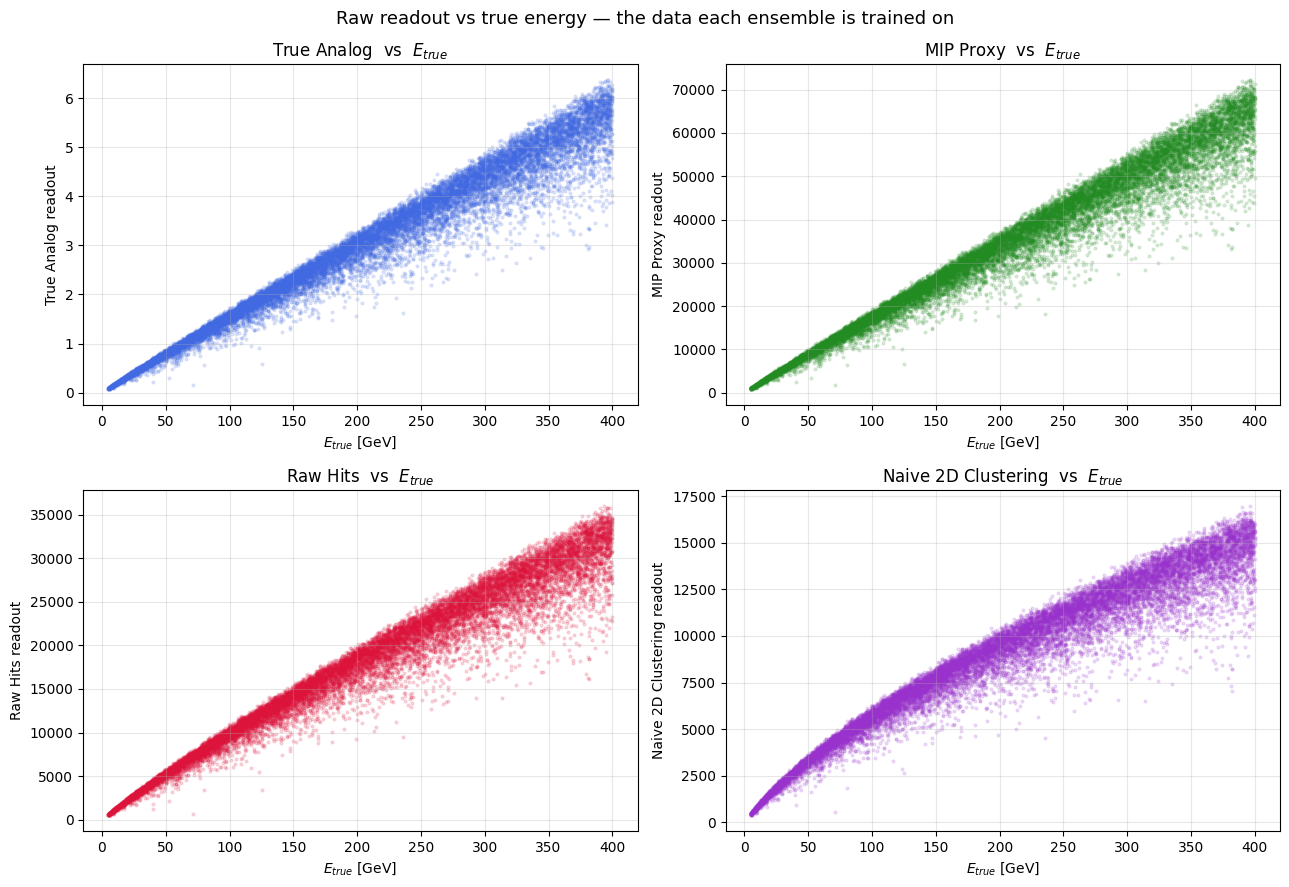

In [4]:
import numpy as np
import matplotlib.pyplot as plt

readouts = {
    "True Analog":          all_visible[valid],
    "MIP Proxy":            all_mip[valid],
    "Raw Hits":             all_hits[valid],
    "Naive 2D Clustering":  all_cluster[valid],
}
colors = {"True Analog": "royalblue", "MIP Proxy": "forestgreen",
          "Raw Hits": "crimson", "Naive 2D Clustering": "darkorchid"}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (name, y) in zip(axes.flat, readouts.items()):
    ax.scatter(x_train, y, s=4, alpha=0.15, color=colors[name])
    ax.set_title(f"{name}  vs  $E_{{true}}$")
    ax.set_xlabel("$E_{true}$ [GeV]")
    ax.set_ylabel(f"{name} readout")
    ax.grid(True, alpha=0.3)
fig.suptitle("Raw readout vs true energy — the data each ensemble is trained on", fontsize=13)
plt.tight_layout()
plt.show()

## 5. What each ensemble learned

Each ensemble is 20 tiny networks. Instead of predicting a single response
value, every network predicts **three quantiles** of the response at a given
`E_true`: the 15.87%, 50%, and 84.13% points — the median and the symmetric ±1σ
envelope of a Gaussian (no Gaussianity is assumed; the
[pinball loss](../analysis/quantilenet.py) simply drives each output to its
target percentile).

So the learned object is not a curve but a **band**:

- the **median** curve is the calibration (typical response vs energy),
- the **half-width** of the band is the intrinsic resolution σ(E) of that readout
  *before* reconstruction.

Overlaying the band on the raw points shows how well 3000 parameters capture the
response.

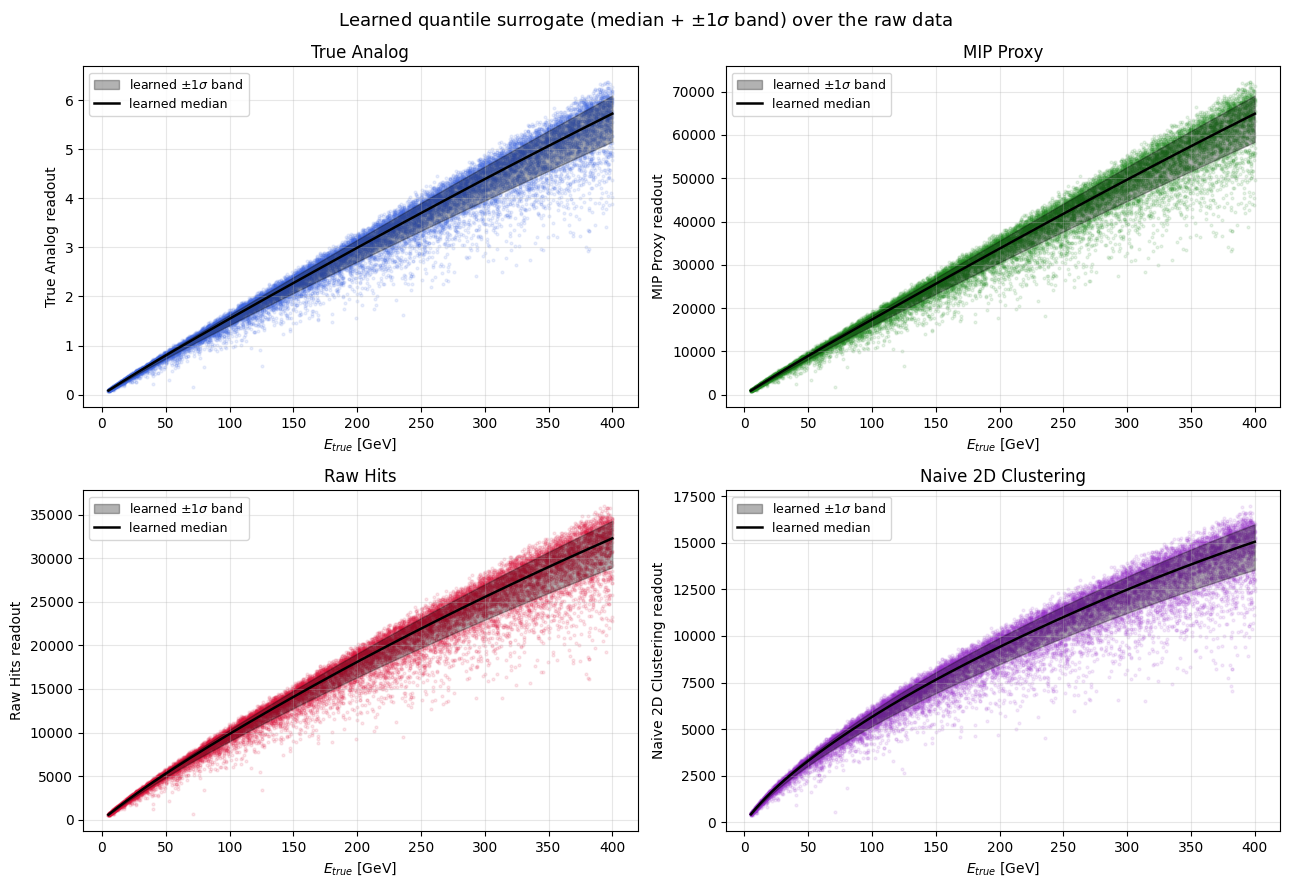

In [5]:
def ensemble_curves(ens, x_max, y_frac_max, e_grid):
    # Ensemble-averaged absolute (low, med, high) readout quantiles vs E.
    xt = torch.tensor(e_grid / x_max, dtype=torch.float32, device=device).unsqueeze(1)
    preds = []
    for m in ens:
        m.eval()
        with torch.no_grad():
            preds.append(m(xt).cpu().numpy())
    avg = np.mean(preds, axis=0) * y_frac_max * e_grid[:, None]
    return avg[:, 0], avg[:, 1], avg[:, 2]

e_grid = np.linspace(5, 400, 400)
ensembles = {
    "True Analog":          (ens_a, xa, ya),
    "MIP Proxy":            (ens_m, xm, ym),
    "Raw Hits":             (ens_h, xh, yh),
    "Naive 2D Clustering":  (ens_c, xc, yc),
}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (name, y) in zip(axes.flat, readouts.items()):
    lo, med, hi = ensemble_curves(*ensembles[name], e_grid)
    ax.scatter(x_train, y, s=4, alpha=0.10, color=colors[name])
    ax.fill_between(e_grid, lo, hi, color="black", alpha=0.30, label=r"learned $\pm1\sigma$ band")
    ax.plot(e_grid, med, color="black", lw=1.8, label="learned median")
    ax.set_title(f"{name}")
    ax.set_xlabel("$E_{true}$ [GeV]")
    ax.set_ylabel(f"{name} readout")
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(True, alpha=0.3)
fig.suptitle(r"Learned quantile surrogate (median + $\pm1\sigma$ band) over the raw data", fontsize=13)
plt.tight_layout()
plt.show()

### Spread across the ensemble

The band above is the *learned* ±1σ of the response. Separately, the **20 networks
disagree** with each other (they each saw a different bootstrap split) — that
disagreement is the **epistemic** uncertainty. Plotting every member's median
curve shows how tightly the ensemble has pinned down the response.

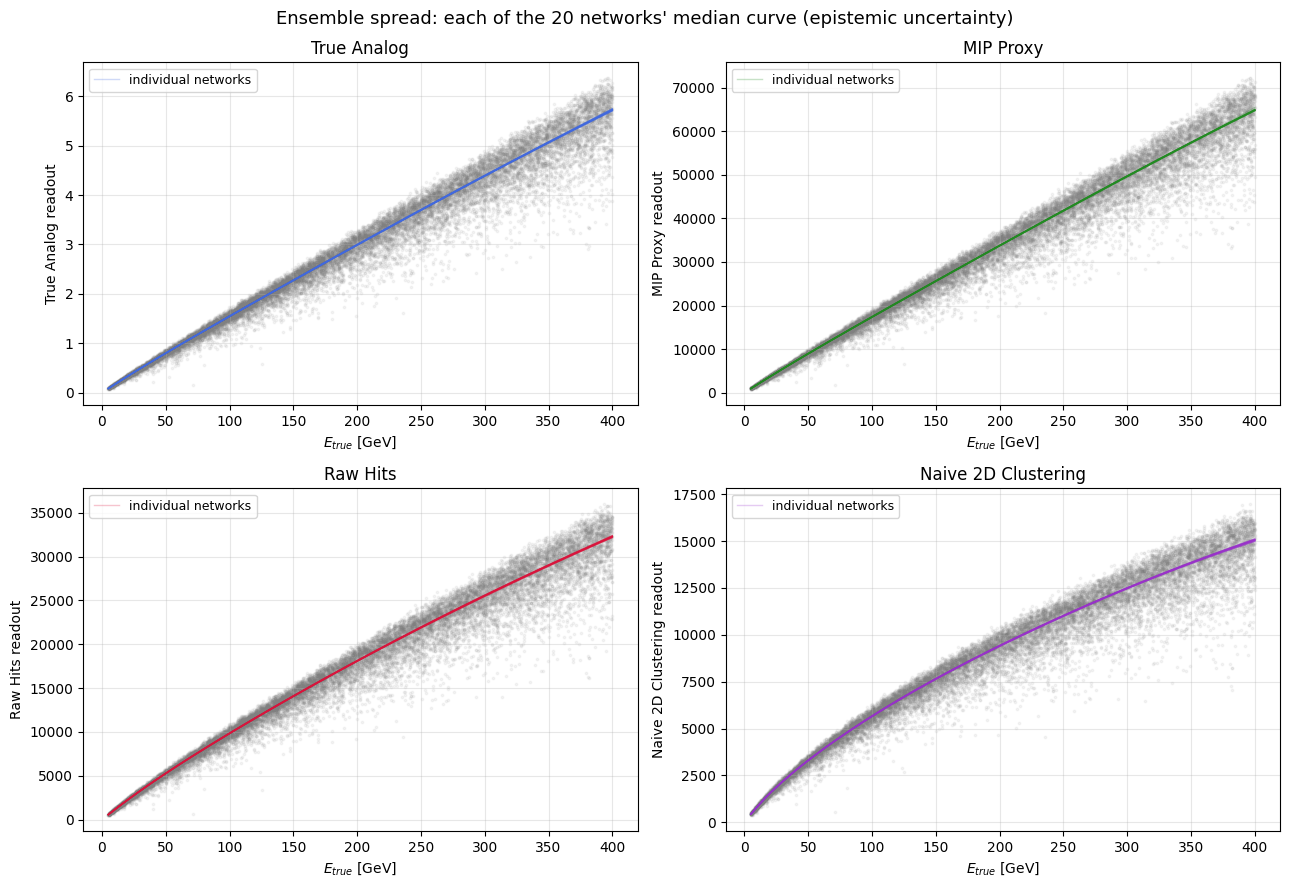

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
e_g = np.linspace(5, 400, 200)
for ax, (name, y) in zip(axes.flat, readouts.items()):
    ens, x_max, y_frac_max = ensembles[name]
    ax.scatter(x_train, y, s=3, alpha=0.08, color="gray")
    xt = torch.tensor(e_g / x_max, dtype=torch.float32, device=device).unsqueeze(1)
    for j, mdl in enumerate(ens):
        mdl.eval()
        with torch.no_grad():
            pa = mdl(xt).cpu().numpy() * y_frac_max * e_g[:, None]
        ax.plot(e_g, pa[:, 1], color=colors[name], lw=1, alpha=0.25,
                label="individual networks" if j == 0 else None)
    ax.set_title(name); ax.set_xlabel("$E_{true}$ [GeV]"); ax.set_ylabel(f"{name} readout")
    ax.legend(loc="upper left", fontsize=9); ax.grid(True, alpha=0.3)
fig.suptitle("Ensemble spread: each of the 20 networks' median curve (epistemic uncertainty)", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Neyman inversion — from a measurement to an energy

The surrogate runs *forward*: `E_true → response`. Reconstruction is the
*inverse*: given a measured readout `y_obs`, what `E_true` produced it, and with
what uncertainty?

We use a [Neyman construction](../docs/DECAL_pipeline.md):

1. The point estimate is `E_reco = f_med⁻¹(y_obs)` — invert the median curve
   (root-find with Brent's method).
2. The ±1σ interval comes from the **crossover**: invert the *lower* quantile
   curve for the upper energy bound, and the *upper* quantile curve for the lower
   bound. Intuitively, a measurement sitting on the low edge of the band is
   consistent with a higher true energy, and vice versa.

The panels below show this for all four readouts at three example true energies.
Where a readout's curves **flatten** (e.g. Raw Hits at high E, as pixels
saturate), the same `y_obs` maps to a much wider energy interval — exactly the
resolution loss the dashboard will quantify.

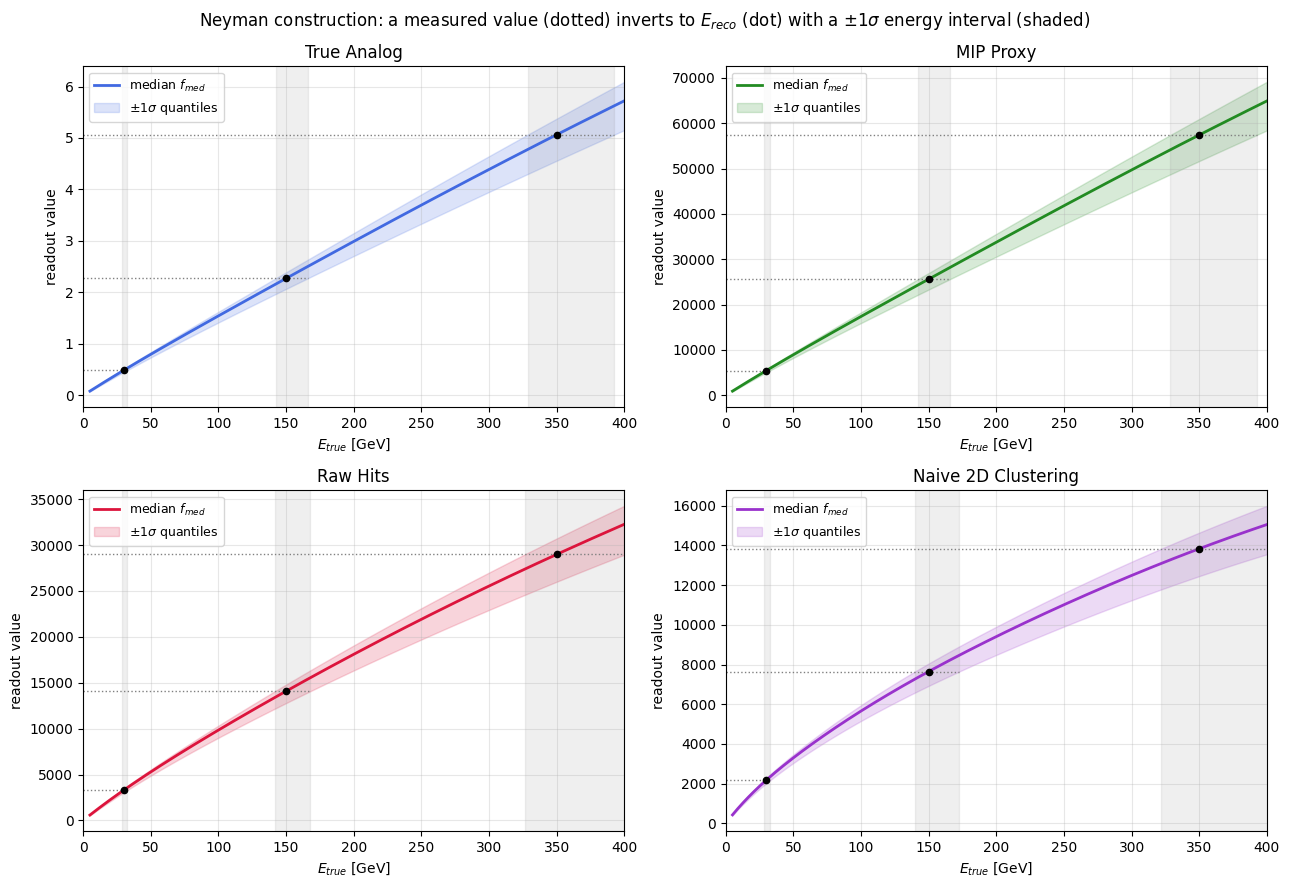

In [7]:
from dashboard import invert_brent

e_grid_inv = np.linspace(1, 500, 1000)   # matches get_interpolators default range
interp = {name: get_interpolators(ens, xm_, ym_, device, e_grid_inv)
          for name, (ens, xm_, ym_) in ensembles.items()}

examples = [30.0, 150.0, 350.0]          # example true energies to invert

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, name in zip(axes.flat, ensembles):
    f_low, f_med, f_high = interp[name]
    eg = np.linspace(5, 400, 400)
    ax.plot(eg, f_med(eg), color=colors[name], lw=2, label=r"median $f_{med}$")
    ax.fill_between(eg, f_low(eg), f_high(eg), color=colors[name], alpha=0.18,
                    label=r"$\pm1\sigma$ quantiles")
    for e_true in examples:
        y_obs  = float(f_med(e_true))
        e_reco = invert_brent(y_obs, f_med)
        e_hi   = invert_brent(y_obs, f_low)    # crossover -> upper bound
        e_lo   = invert_brent(y_obs, f_high)   # crossover -> lower bound
        ax.hlines(y_obs, 0, max(e_hi, e_reco), color="gray", lw=1, ls=":")
        ax.axvspan(e_lo, e_hi, color="gray", alpha=0.12)
        ax.plot([e_reco], [y_obs], "k.", ms=9)
    ax.set_title(f"{name}")
    ax.set_xlabel("$E_{true}$ [GeV]")
    ax.set_ylabel("readout value")
    ax.set_xlim(0, 400)
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(True, alpha=0.3)
fig.suptitle("Neyman construction: a measured value (dotted) inverts to $E_{reco}$ (dot) "
             r"with a $\pm1\sigma$ energy interval (shaded)", fontsize=12)
plt.tight_layout()
plt.show()

## 7. Reconstruct over the full energy grid

Run the inversion across a dense grid of true energies for every readout,
collecting the response ratio (for the closure check above) and the ±1σ
resolution at each energy. The interpolators built in section 6 are reused.

In [8]:
reco = {
    "Analog":  reco_metrics_over_grid(*interp["True Analog"]),
    "MIP":     reco_metrics_over_grid(*interp["MIP Proxy"]),
    "Hits":    reco_metrics_over_grid(*interp["Raw Hits"]),
    "Cluster": reco_metrics_over_grid(*interp["Naive 2D Clustering"]),
}

# Print headline numbers
et = reco["Analog"][0]
print("\n=== reconstructed resolutions (sigma_reco / E_true) ===")
for energy in (10, 100, 300):
    idx = np.argmin(np.abs(et - energy))
    print(f"  E={energy:>3d} GeV:  ", end="")
    for key in ("Analog", "MIP", "Hits", "Cluster"):
        print(f"{key.lower()}={reco[key][2][idx]:.4f}  ", end="")
    print()


=== reconstructed resolutions (sigma_reco / E_true) ===
  E= 10 GeV:  analog=0.0686  mip=0.0696  hits=0.0684  cluster=0.0716  
  E=100 GeV:  analog=0.0744  mip=0.0744  hits=0.0802  cluster=0.0991  
  E=300 GeV:  analog=0.0891  mip=0.0886  hits=0.1025  cluster=0.1233  


## 8. How well does the inversion close?

Reconstruction should be **unbiased**: feeding the median response of a true
energy back through the inverse must return that same energy. The left panel
checks closure (`E_reco` vs `E_true`, should lie on `y = x`); the right panel is
the bias `E_reco/E_true − 1` in percent — flat at zero means a faithful
inversion.

This closure is *near-perfect by construction* (we invert the same median we
built), so it is a sanity check, not a resolution measurement — the real physics
is the band *width*, shown in the dashboard next. See
[handbook §13.1](../docs/handbook.md) for the caveat.

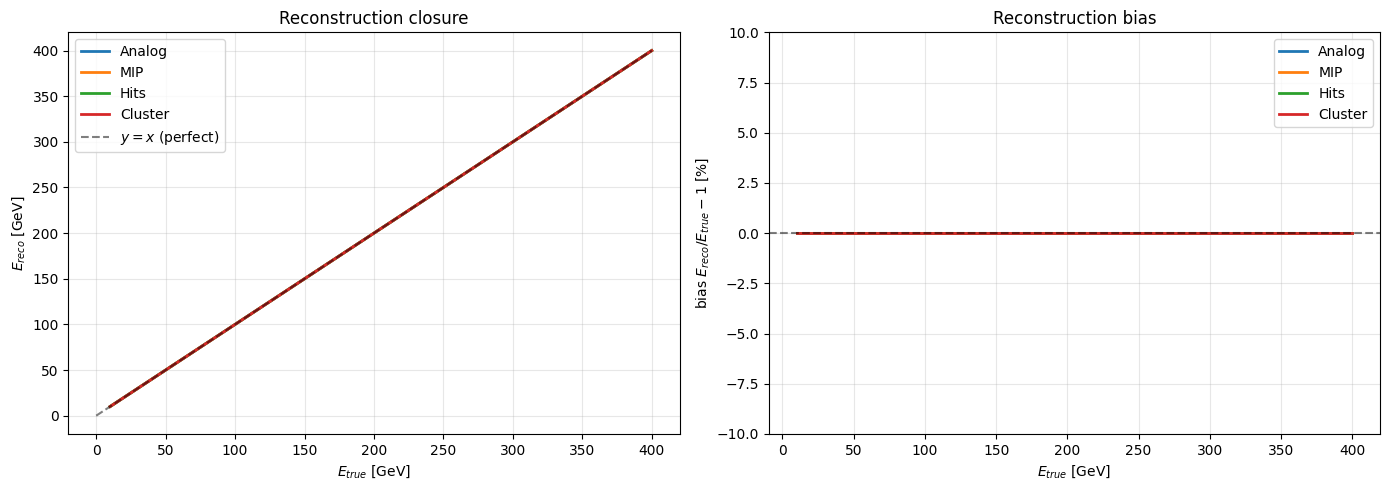

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for key in ("Analog", "MIP", "Hits", "Cluster"):
    e_t, resp, res = reco[key]
    axes[0].plot(e_t, e_t * resp, lw=2, label=key)
axes[0].plot([0, 400], [0, 400], "k--", alpha=0.5, label="$y=x$ (perfect)")
axes[0].set_xlabel("$E_{true}$ [GeV]"); axes[0].set_ylabel("$E_{reco}$ [GeV]")
axes[0].set_title("Reconstruction closure"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

for key in ("Analog", "MIP", "Hits", "Cluster"):
    e_t, resp, res = reco[key]
    axes[1].plot(e_t, (resp - 1.0) * 100, lw=2, label=key)
axes[1].axhline(0, color="black", ls="--", alpha=0.5)
axes[1].set_ylim(-10, 10)
axes[1].set_xlabel("$E_{true}$ [GeV]"); axes[1].set_ylabel(r"bias $E_{reco}/E_{true}-1$ [%]")
axes[1].set_title("Reconstruction bias"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. The resolution dashboard

The payoff. Three panels: reconstructed linearity, resolution vs energy (the
saturation knee), and the stochastic term (σ/E vs 1/√E).

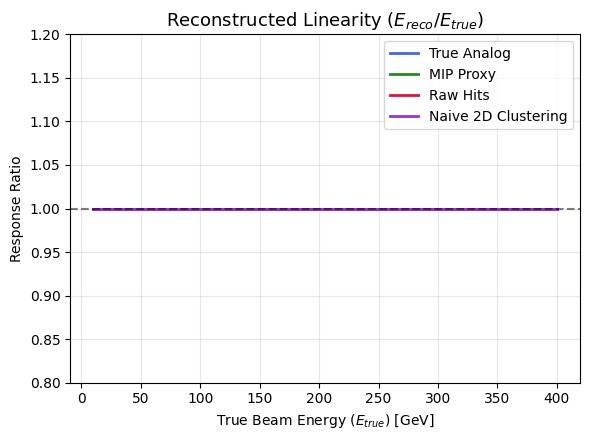

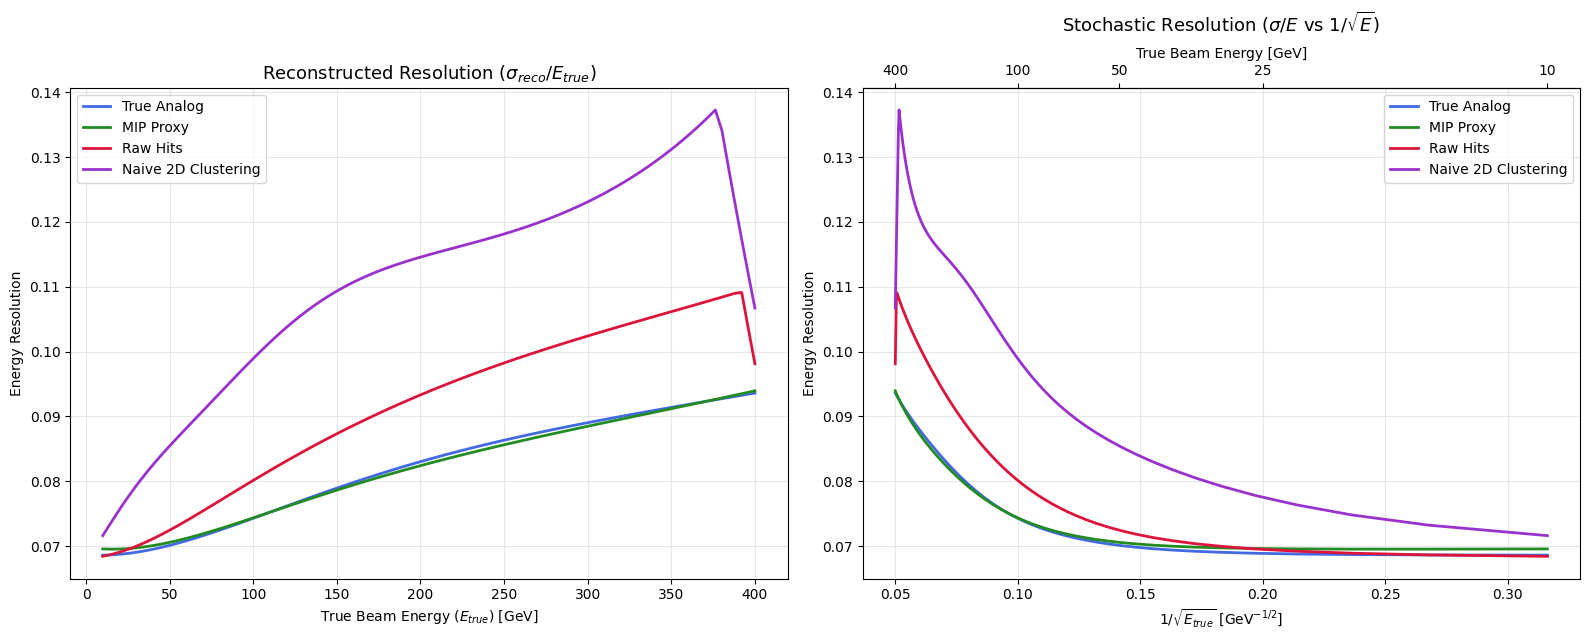

In [10]:
plot_dashboard(reco, out_path_prefix=None, show=True)


## What to look for in the dashboard

**Panel 1 — Linearity** (`E_reco / E_true`): should sit flat at 1.0. *This is partially trivial* (we're inverting the median surrogate with itself) — see [`docs/handbook.md`](../docs/handbook.md) §13.1 for caveats.

**Panel 2 — Resolution** (`σ_reco / E_true` vs `E_true`): the DECAL physics. Analog and MIP curves should overlap (they're the "ideal" readouts). Raw Hits should diverge upward at high energy as **pixel saturation** kicks in — that's the saturation breakdown around ~100 GeV at 100 µm pixel pitch.

**Panel 3 — Stochastic** (`σ_reco / E_true` vs `1/√E_true`): straight line through origin = pure stochastic resolution `a/√E`. Deviations on the right side (low E) = sampling-fluctuation regime. Curving-up on the left (high E) = constant-term contributions from saturation/leakage.

For physics interpretation see [`docs/DECAL_pipeline.md`](../docs/DECAL_pipeline.md) §6 and [`docs/handbook.md`](../docs/handbook.md) §13.


## Suggested follow-up experiments

1. **Pixel pitch scan**: re-run the entire pipeline at 25, 50, 200 µm pixel pitch (edit `ECal_cell_size` in `geometry/SiD_TestBeam.xml`, regenerate sim, re-extract, retrain). Plot how the saturation knee moves.
2. **Particle type**: change `gun.particle` in `sim/run_sim.py` to `"pi+"` or `"proton"`. Hadronic showers spread differently — how does the resolution change?
3. **More models per ensemble**: edit `num_models=20` in `analysis/train_ensembles.py`. Does the resolution prediction tighten with more bootstrap samples?
4. **Held-out test set**: the current linearity panel is trivially perfect because we use the same curve for forward and inverse. Modify the pipeline to bootstrap-resample real events and reconstruct each one — what does linearity look like then?
